Celda 1: Importación de Librerías y Configuración (Enfoque Clasificación)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines de scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de Clasificación
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Métricas de Clasificación
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Integración de TabPFN v3 para Clasificación (Ignorando límites de CPU)
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Celda 2: [1.1] Carga de Datos e Inspección Básica (0.5 ptos)

In [ ]:
# Carga de los datos de depósitos bancarios
df = pd.read_csv('data/tbank_term_deposit.csv')

print(f"Dimensiones iniciales del dataset: {df.shape}")
print(f"Distribución del split original:\n{df['split'].value_counts()}\n")

# 1. Separación estricta usando la columna 'split'
df_labeled = df[df['split'] == 'labeled'].copy()
df_leaderboard = df[df['split'] == 'leaderboard'].copy()

# 2. Mapeo seguro del target únicamente sobre el conjunto etiquetado (para evitar Data Leakage)
target_col = 'y'
df_labeled[target_col] = df_labeled[target_col].map({'yes': 1, 'no': 0, 'true': 1, 'false': 0}).astype(int)

print(f"Dimensiones del set de entrenamiento/validación (labeled): {df_labeled.shape}")
print(f"Dimensiones del set de test final sin etiquetas (leaderboard): {df_leaderboard.shape}")

# Inspección de los tipos de datos del set etiquetado
df_labeled.info()

Dimensiones iniciales del dataset: (3063, 19)
Distribución del split original:
split
labeled        2007
leaderboard    1056
Name: count, dtype: int64

Dimensiones del set de entrenamiento/validación (labeled): (2007, 19)
Dimensiones del set de test final sin etiquetas (leaderboard): (1056, 19)
<class 'pandas.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         2007 non-null   int64
 1   split      2007 non-null   str  
 2   age        2007 non-null   int64
 3   job        2007 non-null   str  
 4   marital    2007 non-null   str  
 5   education  2007 non-null   str  
 6   default    2007 non-null   str  
 7   balance    2007 non-null   int64
 8   housing    2007 non-null   str  
 9   loan       2007 non-null   str  
 10  contact    2007 non-null   str  
 11  day        2007 non-null   int64
 12  month      2007 non-null   str  
 13  duration   2007 non-null   int64


Celda 3: [1.2] Exploración de los Datos (EDA): Distribuciones y Correlaciones (1.0 pto)

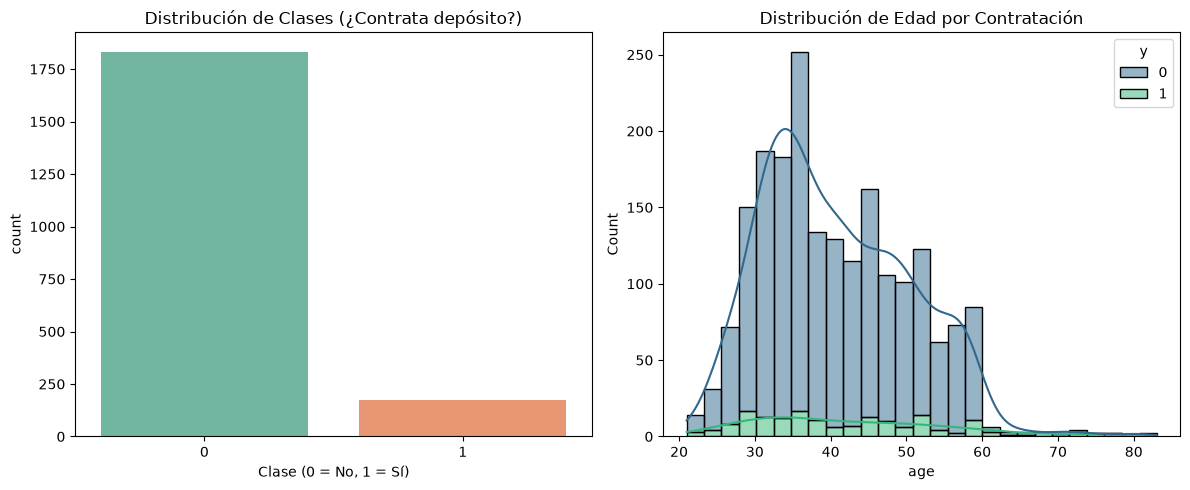

In [3]:
plt.figure(figsize=(12, 5))

# Gráfico de balance de clases (Distribución de la variable objetivo en el set etiquetado)
plt.subplot(1, 2, 1)
sns.countplot(data=df_labeled, x=target_col, palette='Set2')
plt.title('Distribución de Clases (¿Contrata depósito?)')
plt.xlabel('Clase (0 = No, 1 = Sí)')

# Histograma de distribución de edad según la contratación
plt.subplot(1, 2, 2)
sns.histplot(data=df_labeled, x='age', hue=target_col, multiple='stack', kde=True, palette='viridis')
plt.title('Distribución de Edad por Contratación')

plt.tight_layout()
plt.show()

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Distribución: Se observa un desbalance de clases marcado (la mayoría de los clientes no contratan el depósito). 
# Esto justifica el uso de StratifiedKFold y la métrica F1-Score para evaluar de forma realista el modelo."

Celda 4: [2.1] Preparación de los Datos: Limpieza - Nulos, Outliers y Duplicados (1.5 ptos)

Recuento de nulos por columna en datos etiquetados:
No se detectaron valores nulos inicialmente.


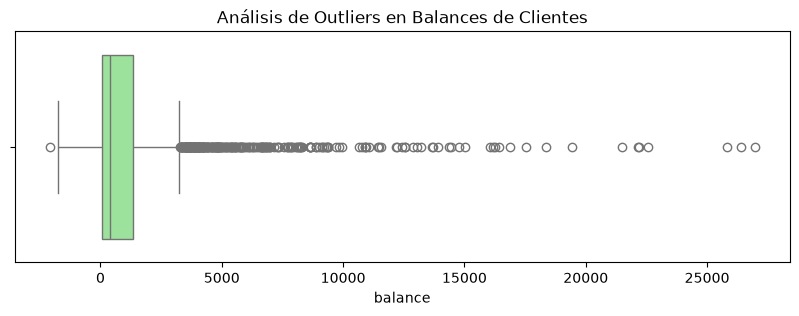

Número de registros duplicados detectados: 0


In [4]:
# --- 3.1. ANÁLISIS DE NULOS ---
missing_data = df_labeled.isnull().sum()
print("Recuento de nulos por columna en datos etiquetados:")
print(missing_data[missing_data > 0] if missing_data.any() else "No se detectaron valores nulos inicialmente.")

# --- 3.2. ANÁLISIS DE OUTLIERS ---
if 'balance' in df_labeled.columns:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_labeled['balance'], color='lightgreen')
    plt.title('Análisis de Outliers en Balances de Clientes')
    plt.show()

# --- 3.3. ANÁLISIS DE DUPLICADOS ---
duplicates = df_labeled.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicates}")
if duplicates > 0:
    df_labeled = df_labeled.drop_duplicates()
    print("Registros duplicados eliminados.")

Celda 5: [2.2] Feature Engineering (1.75 ptos)

In [5]:
df_fe = df_labeled.copy()

# 4.1. Ingeniería de características (pdays)
if 'pdays' in df_fe.columns:
    df_fe['was_previously_contacted'] = (df_fe['pdays'] != -1).astype(int)

# 4.2. Definición final de X e y (Eliminando id, split e y)
X = df_fe.drop(columns=['id', 'split', target_col])
y = df_fe[target_col]

print(f"Variables predictoras seleccionadas: {list(X.columns)}")

Variables predictoras seleccionadas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'was_previously_contacted']


Celda 6: [3.1] Diseño del Testeo y Validación (0.5 ptos)

In [6]:
# Train-Test Split (80/20) estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

# Definición de la estrategia de validación cruzada para optimización
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Entrenamiento: {X_train.shape} | Test de Validación Interno: {X_test.shape}")

Entrenamiento: (1605, 17) | Test de Validación Interno: (402, 17)


Celda 7: Preprocesador Multivariante (Pipelines de Limpieza y Encoding)

In [7]:
# Identificamos columnas según su tipo
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline numérico: Imputación con mediana y estandarización
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: Imputación por moda y One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblamos el preprocesador dinámico
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Diccionario global para recolectar las métricas de los modelos evaluados
results_summary = {}

def run_classification_evaluation(model_name, pipeline, X_tr, y_tr, X_te, y_te):
    """Ajusta, evalúa con Validación Cruzada (F1-score) y testea de forma interna un modelo."""
    cv_res = cross_validate(pipeline, X_tr, y_tr, cv=cv_strategy, scoring='f1')
    cv_f1 = cv_res['test_score'].mean()
    cv_std = cv_res['test_score'].std()
    
    # Entrenamiento completo en Train y prueba interna
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    
    test_accuracy = accuracy_score(y_te, preds)
    test_f1 = f1_score(y_te, preds)
    
    results_summary[model_name] = {
        'CV F1 Mean': cv_f1,
        'CV F1 Std': cv_std,
        'Test Accuracy': test_accuracy,
        'Test F1-Score': test_f1
    }
    print(f"[{model_name}] -> CV F1: {cv_f1:.4f} (±{cv_std:.4f}) | Test Acc: {test_accuracy:.4f} | Test F1: {test_f1:.4f}")

Celda 8: [3.2.1] Clasificador Baseline (Dummy Classifier) (0.25 ptos)

In [8]:
# Configuración del clasificador baseline
dummy_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

run_classification_evaluation('Dummy (Most Frequent)', dummy_pipe, X_train, y_train, X_test, y_test)

[Dummy (Most Frequent)] -> CV F1: 0.0000 (±0.0000) | Test Acc: 0.9129 | Test F1: 0.0000


Celda 9: [3.2.2] Modelos de ML Base (Logistic Regression, RF y HistGradientBoosting)

In [9]:
# 1. Regresión Logística
lr_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))])
run_classification_evaluation('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test)

# 2. Random Forest Classifier
rf_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=42))])
run_classification_evaluation('Random Forest (Base)', rf_base_pipe, X_train, y_train, X_test, y_test)

# 3. HistGradientBoosting Classifier
hgb_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingClassifier(random_state=42))])
run_classification_evaluation('HistGradientBoosting (Base)', hgb_base_pipe, X_train, y_train, X_test, y_test)

[Logistic Regression] -> CV F1: 0.7497 (±0.0484) | Test Acc: 0.9577 | Test F1: 0.7606
[Random Forest (Base)] -> CV F1: 0.7412 (±0.0198) | Test Acc: 0.9577 | Test F1: 0.7385
[HistGradientBoosting (Base)] -> CV F1: 0.7544 (±0.0223) | Test Acc: 0.9652 | Test F1: 0.8056


Celda 10: [3.2.2] Ajuste Fino de Hiperparámetros (Tuning) de RF y HGB

In [10]:
# Búsqueda aleatoria para Random Forest
param_dist_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [8, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', None]
}
search_rf = RandomizedSearchCV(rf_base_pipe, param_distributions=param_dist_rf, 
                               n_iter=5, cv=cv_strategy, scoring='f1', 
                               random_state=42, n_jobs=-1)
search_rf.fit(X_train, y_train)
run_classification_evaluation('Random Forest (Tuned)', search_rf.best_estimator_, X_train, y_train, X_test, y_test)

# Búsqueda aleatoria para HistGradientBoosting
param_dist_hgb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 10],
    'model__class_weight': ['balanced', None]
}
search_hgb = RandomizedSearchCV(hgb_base_pipe, param_distributions=param_dist_hgb, 
                                n_iter=5, cv=cv_strategy, scoring='f1', 
                                random_state=42, n_jobs=-1)
search_hgb.fit(X_train, y_train)
run_classification_evaluation('HistGradientBoosting (Tuned)', search_hgb.best_estimator_, X_train, y_train, X_test, y_test)

[Random Forest (Tuned)] -> CV F1: 0.7914 (±0.0399) | Test Acc: 0.9602 | Test F1: 0.7838
[HistGradientBoosting (Tuned)] -> CV F1: 0.7738 (±0.0367) | Test Acc: 0.9502 | Test F1: 0.7500


Celda 11: [3.2.2] Modelo de Clasificación de Vanguardia: TabPFN v3 Classifier

In [11]:
ckpt_classifier_path = r"C:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\tabpfn_driver\tabpfn_3\tabpfn-v3-classifier-v3_20260417_binary.ckpt"

if TABPFN_AVAILABLE:
    if os.path.exists(ckpt_classifier_path):
        print("¡Excelente! Checkpoint de clasificación binaria detectado localmente.")
        tabpfn_classifier = TabPFNClassifier(
            model_path=ckpt_classifier_path, 
            device='cpu', 
            ignore_pretraining_limits=True
        )
        
        tabpfn_pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', tabpfn_classifier)
        ])
        
        run_classification_evaluation('TabPFN v3 Classifier', tabpfn_pipe, X_train, y_train, X_test, y_test)
    else:
        print(f"Error: No se encuentra el checkpoint en {ckpt_classifier_path}")
else:
    print("El framework TabPFN v3 no está instalado o accesible en este entorno virtual.")

Error: No se encuentra el checkpoint en C:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\tabpfn_driver\tabpfn_3\tabpfn-v3-classifier-v3_20260417_binary.ckpt


Celda 12: [4.1 / 4.2] Tabla Comparativa y Evaluación Final (1.0 pto

=== TABLA COMPARATIVA DE CLASIFICACIÓN (Ordenada por Test F1-Score) ===


,CV F1 Mean,CV F1 Std,Test Accuracy,Test F1-Score
HistGradientBoosting (Base),0.754358,0.022289,0.965174,0.805556
Random Forest (Tuned),0.791417,0.039888,0.960199,0.783784
Logistic Regression,0.749667,0.048447,0.957711,0.760563
HistGradientBoosting (Tuned),0.773837,0.036656,0.950249,0.750000
Random Forest (Base),0.741165,0.019758,0.957711,0.738462
Dummy (Most Frequent),0.000000,0.000000,0.912935,0.000000


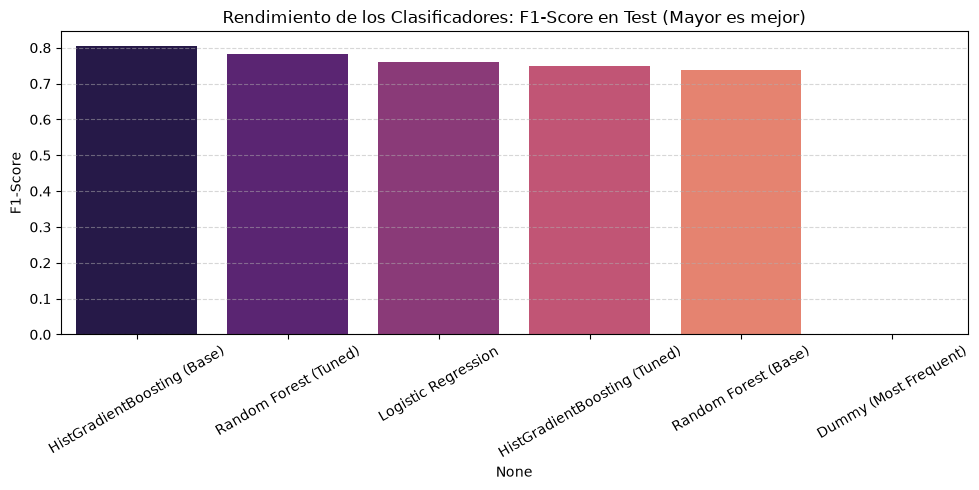

In [12]:
df_results = pd.DataFrame(results_summary).T.sort_values(by='Test F1-Score', ascending=False)

print("=== TABLA COMPARATIVA DE CLASIFICACIÓN (Ordenada por Test F1-Score) ===")
display(df_results)

# Gráfico de barras de rendimiento
plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['Test F1-Score'], palette='magma')
plt.title('Rendimiento de los Clasificadores: F1-Score en Test (Mayor es mejor)')
plt.ylabel('F1-Score')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Celda 13: [5.0] Exportación de Predicciones Binarias a CSV y Conclusiones (1.0 pto)

In [13]:
# 1. Escogemos dinámicamente el modelo con mejor puntuación F1-Score en Test
best_model_name = df_results.index[0]
print(f"El clasificador óptimo seleccionado es: {best_model_name}\n")

if best_model_name == 'HistGradientBoosting (Tuned)':
    final_pipeline = search_hgb.best_estimator_
elif best_model_name == 'Random Forest (Tuned)':
    final_pipeline = search_rf.best_estimator_
elif best_model_name == 'TabPFN v3 Classifier' and TABPFN_AVAILABLE:
    final_pipeline = tabpfn_pipe
else:
    final_pipeline = hgb_base_pipe  # Respaldo robusto

# 2. Reentrenamos el Pipeline ganador con la totalidad del set etiquetado (X, y)
final_pipeline.fit(X, y)

# 3. Preparamos las características del conjunto 'leaderboard' (Test real de negocio)
# Aplicamos la misma ingeniería de características al set sin etiquetas
df_leaderboard_fe = df_leaderboard.copy()
if 'pdays' in df_leaderboard_fe.columns:
    df_leaderboard_fe['was_previously_contacted'] = (df_leaderboard_fe['pdays'] != -1).astype(int)

# Eliminamos variables de control id, split e y (la cual es NaN aquí)
X_leaderboard = df_leaderboard_fe.drop(columns=['id', 'split', 'y'])

# 4. Predecimos sobre el conjunto leaderboard
leaderboard_preds = final_pipeline.predict(X_leaderboard)

# 5. Guardamos las predicciones ligadas al ID original de las filas del leaderboard
output_df = pd.DataFrame({
    'id': df_leaderboard['id'],
    'prediction': leaderboard_preds.astype(int)
})

output_csv_name = 'predictions_bank_final.csv'
output_df.to_csv(output_csv_name, index=False)

print(f"Archivo generado con éxito: '{output_csv_name}'")
print(f"Conteo de predicciones generadas para el negocio:\n{output_df['prediction'].value_counts()}\n")
print("Muestra de los primeros 10 registros del archivo generado:")
display(output_df.head(10))

El clasificador óptimo seleccionado es: HistGradientBoosting (Base)

Archivo generado con éxito: 'predictions_bank_final.csv'
Conteo de predicciones generadas para el negocio:
prediction
0    982
1     74
Name: count, dtype: int64

Muestra de los primeros 10 registros del archivo generado:


,id,prediction
2007,2466,0
2008,2467,0
2009,2468,1
2010,2469,0
2011,2470,0
2012,2471,0
2013,2472,0
2014,2473,0
2015,2474,0
2016,2475,0
